# Joint DFE High-r Production: Demography & DFE Inference Results

In [ ]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats.distributions as ssd

BASE_DIR = "/Users/srgib/GitHub/dadi_polyploidy/thesis_figures/SLiM_DFE_results/Joint_DFE_migration"
DEMOG_DIR = os.path.join(BASE_DIR, "demography")
DFE_DIR = os.path.join(BASE_DIR, "DFE")

REP_RE = re.compile(r'REP_(\d+)')

# joint DFE: lognormal with sigma as the scipy shape parameter and scale=np.exp(mu),
# i.e. scipy.stats.distributions.lognorm(sigma, scale=np.exp(mu))
TRUE_MU = 1.69155136
TRUE_SIGMA = 2.37871223
TRUE_W = 0.075

method_colors = {
    'dadi_nomisid': "#1f77b4",
    'dadi_misid': "#ff7f0e",
}
method_labels = {
    'dadi_nomisid': 'dadi (no misid)',
    'dadi_misid': 'dadi (misid)',
}


def get_best_fit_params(opt_file):
    """
    Load the best-fit row (highest log-likelihood < 0) from a dadi
    optimization results file, keyed by that file's own header. Works for
    both demography and DFE optimization files, with or without a misid
    column, since the parameter names are read from the header rather
    than passed in.
    """
    with open(opt_file, 'r') as f:
        lines = f.readlines()
    param_names = lines[0].strip().split('\t')[1:]

    best_line, best_ll = None, float('-inf')
    for line in lines[1:]:
        parts = line.strip().split('\t')
        ll = float(parts[0])
        if (ll > best_ll) and (ll < 0):
            best_ll = ll
            best_line = parts

    return {name: float(best_line[i + 1]) for i, name in enumerate(param_names)}


def load_replicates(directory, file_prefix, parser):
    """Map REP number -> parsed parameter dict for every matching file in `directory`."""
    results = {}
    for path in glob.glob(os.path.join(directory, f"{file_prefix}*.txt")):
        rep = int(REP_RE.search(os.path.basename(path)).group(1))
        results[rep] = parser(path)
    return results


## Demographic parameter estimates

In [2]:
# four demographic inference configurations: {small, large} x {misid, no misid}
# (no medium size for Joint DFE)
demog_configs = {
    'small': 'bg_sc_small',
    'large': 'bg_sc_large',
    'small_misid': 'bg_sc_misid_small',
    'large_misid': 'bg_sc_misid_large',
}

demog_data = {
    label: load_replicates(os.path.join(DEMOG_DIR, folder), 'optimization_', get_best_fit_params)
    for label, folder in demog_configs.items()
}


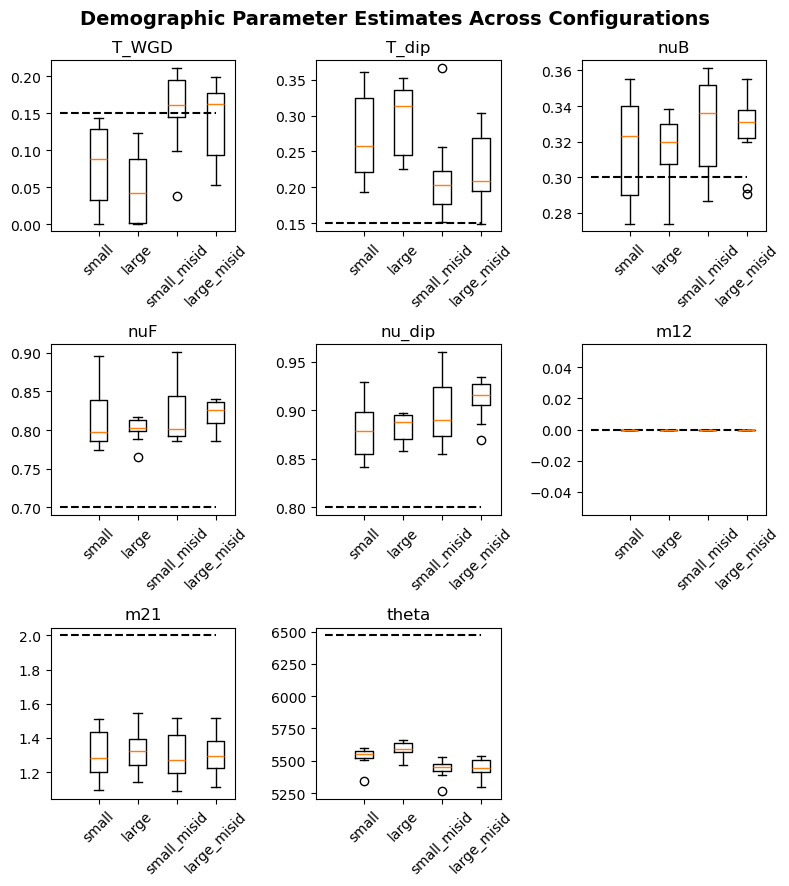

In [8]:
# T_WGD, T_dip, nuB, nuF, nu_dip, and theta are estimated in all four configs; misid only in the two *_misid configs
demog_params = ['T_WGD', 'T_dip', 'nuB', 'nuF', 'nu_dip', 'm12', 'm21', 'theta']

theta_true_syn = 161744 * 4 * 5e6 * 7e-9 * (1/3.5)
true_vals = [0.15, 0.15, 0.3, 0.7, 0.8, 0.0, 2.0, theta_true_syn, 0]

fig, axes = plt.subplots(3, 3, figsize=(8, 9))
axes = axes.flatten()

for ax, param, true_val in zip(axes, demog_params, true_vals):
    labels = [label for label, reps in demog_data.items() if param in next(iter(reps.values()))]
    values = [[rep_params[param] for rep_params in demog_data[label].values()] for label in labels]
    ax.boxplot(values, tick_labels=labels)
    ax.set_title(param)
    ax.tick_params(axis='x', rotation=45)
    ax.hlines(true_val, xmin=0, xmax=len(labels), color='black', linestyle='dashed')

for ax in axes[len(demog_params):]:
    ax.axis('off')
fig.suptitle('Demographic Parameter Estimates Across Configurations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'demography_boxplots.pdf'), bbox_inches='tight')
plt.show()


## DFE inference: location & scale

In [11]:
# for each size, the no-misid and misid runs live in separate folders, holding dadi's
# DFE_optimization_* results only -- fastDFE results aren't available here since fastDFE only
# supports inference from a single population, but this joint DFE spans two subgenomes
dfe_dirs = {
    'large': {'nomisid': 'bg_sc_large', 'misid': 'bg_sc_misid_large'},
}

# dfe_shape_scale[size][method] -> list of (mu, sigma) pairs over the 10 replicates
# dfe_w[size][method] -> list of w values (weight on the subgenome-decorrelated 2d component) over the 10 replicates
dfe_shape_scale = {}
dfe_w = {}
for size, dirs in dfe_dirs.items():
    shape_scale_entry = {}
    w_entry = {}
    for tag, folder in dirs.items():
        d = os.path.join(DFE_DIR, folder)
        dadi_reps = load_replicates(d, 'DFE_optimization_', get_best_fit_params)

        # the joint DFE is parameterized directly in mu / sigma for the lognormal distribution
        shape_scale_entry[f'dadi_{tag}'] = [(p['mu'], p['sigma']) for p in dadi_reps.values()]
        w_entry[f'dadi_{tag}'] = [p['w'] for p in dadi_reps.values()]
    dfe_shape_scale[size] = shape_scale_entry
    dfe_w[size] = w_entry

dfe_methods = ['dadi_nomisid', 'dadi_misid']


ValueError: not enough values to unpack (expected 2, got 0)

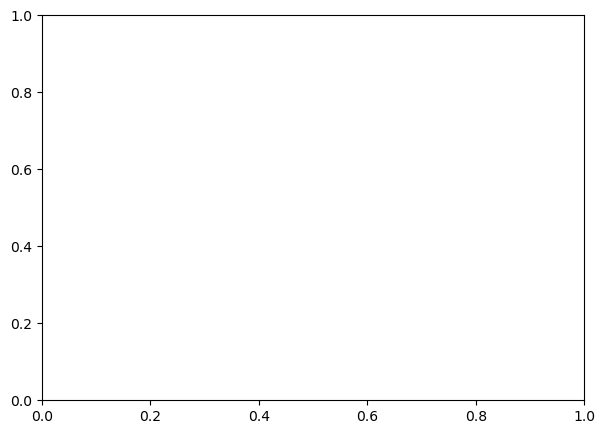

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for method in dfe_methods:
    mus, sigmas = zip(*dfe_shape_scale['small'][method])
    ax.scatter(mus, sigmas, label=method_labels[method], color=method_colors[method],
               s=70, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(TRUE_MU, TRUE_SIGMA, marker='x', color='black', s=100, linewidths=2.5,
           zorder=5, label='True values')

# iso-mean contour: exp(mu + sigma^2/2) = true mean, the constant-mean curve passing through the true point
xlim = ax.get_xlim()
true_mean = np.exp(TRUE_MU + TRUE_SIGMA**2 / 2)
mu_range = np.linspace(*xlim, 200)
with np.errstate(invalid='ignore'):
    sigma_curve = np.sqrt(2 * (np.log(true_mean) - mu_range))
ax.plot(mu_range, sigma_curve, linestyle='--', color='gray', linewidth=1.5,
        zorder=2, label='Constant mean (exp(mu + sigma^2/2) = true mean)')
ax.set_xlim(xlim)

ax.set_xlabel(r'Location ($\mu$)')
ax.set_ylabel(r'Scale ($\sigma$)')
ax.set_title('DFE Inference: small')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_scatter_small.pdf'), bbox_inches='tight')
plt.show()


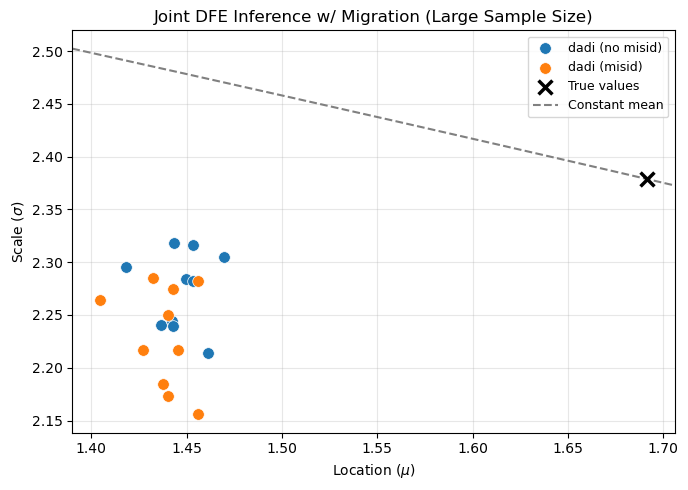

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
for method in dfe_methods:
    mus, sigmas = zip(*dfe_shape_scale['large'][method])
    ax.scatter(mus, sigmas, label=method_labels[method], color=method_colors[method],
               s=70, edgecolors='white', linewidths=0.5, zorder=3)

ax.scatter(TRUE_MU, TRUE_SIGMA, marker='x', color='black', s=100, linewidths=2.5,
           zorder=5, label='True values')

# iso-mean contour: exp(mu + sigma^2/2) = true mean, the constant-mean curve passing through the true point
xlim = ax.get_xlim()
true_mean = np.exp(TRUE_MU + TRUE_SIGMA**2 / 2)
mu_range = np.linspace(*xlim, 200)
with np.errstate(invalid='ignore'):
    sigma_curve = np.sqrt(2 * (np.log(true_mean) - mu_range))
ax.plot(mu_range, sigma_curve, linestyle='--', color='gray', linewidth=1.5,
        zorder=2, label='Constant mean')
ax.set_xlim(xlim)

ax.set_xlabel(r'Location ($\mu$)')
ax.set_ylabel(r'Scale ($\sigma$)')
ax.set_title('Joint DFE Inference w/ Migration (Large Sample Size)')
ax.legend(fontsize=9, framealpha=0.8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_scatter_large.pdf'), bbox_inches='tight')
plt.show()


## DFE inference: mixture weight (w)

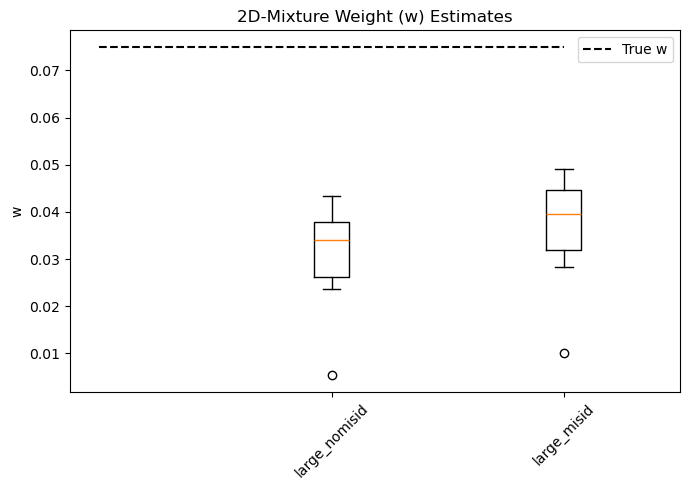

In [16]:
w_labels = [f'{size}_{tag.replace("dadi_", "")}' for size in dfe_w for tag in dfe_methods]
w_values = [dfe_w[size][tag] for size in dfe_w for tag in dfe_methods]

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(w_values, tick_labels=w_labels)
ax.hlines(TRUE_W, xmin=0, xmax=len(w_labels), color='black', linestyle='dashed', label='True w')
ax.set_title('2D-Mixture Weight (w) Estimates')
ax.set_ylabel('w')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_w_boxplot.pdf'), bbox_inches='tight')
plt.show()


## Discretized DFE

In [20]:
bin_labels = ("gamma<2", "2<gamma<20", "20<gamma<200", "gamma>200")
group_colors = {'true': '#000000', **method_colors}
group_labels = {'true': 'True lognormal', **method_labels}


def discretized_bins(mu, sigma):
    """Proportion of a lognormal(mu, sigma) distribution falling in each of the four 2Ns bins."""
    c1 = ssd.lognorm.cdf(2, sigma, scale=np.exp(mu))
    c10 = ssd.lognorm.cdf(20, sigma, scale=np.exp(mu))
    c100 = ssd.lognorm.cdf(200, sigma, scale=np.exp(mu))
    return [c1, c10 - c1, c100 - c10, 1 - c100]


def average_bins(mu_sigma_pairs):
    """
    Average the discretized bins across replicates rather than averaging
    mu/sigma first, since the mean of several lognormal distributions'
    parameters does not itself define a lognormal distribution.
    """
    bins = np.array([discretized_bins(mu, sigma) for mu, sigma in mu_sigma_pairs])
    return bins.mean(axis=0)


true_bins = discretized_bins(TRUE_MU, TRUE_SIGMA)


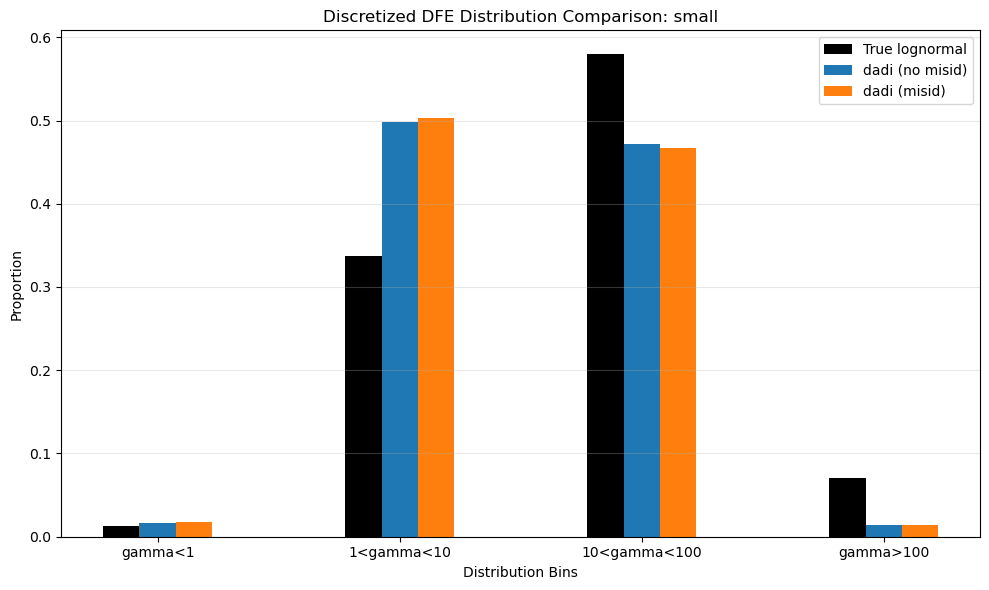

In [9]:
groups = ['true'] + dfe_methods
bin_vals = {'true': true_bins}
for method in dfe_methods:
    bin_vals[method] = average_bins(dfe_shape_scale['small'][method])

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
n_groups = len(groups)
bar_width = 0.15
bin_positions = np.arange(n_bins)

for i, group in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(bin_positions + offset, bin_vals[group], bar_width,
           label=group_labels[group], color=group_colors[group])

ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison: small')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_discretized_small.pdf'), bbox_inches='tight')
plt.show()


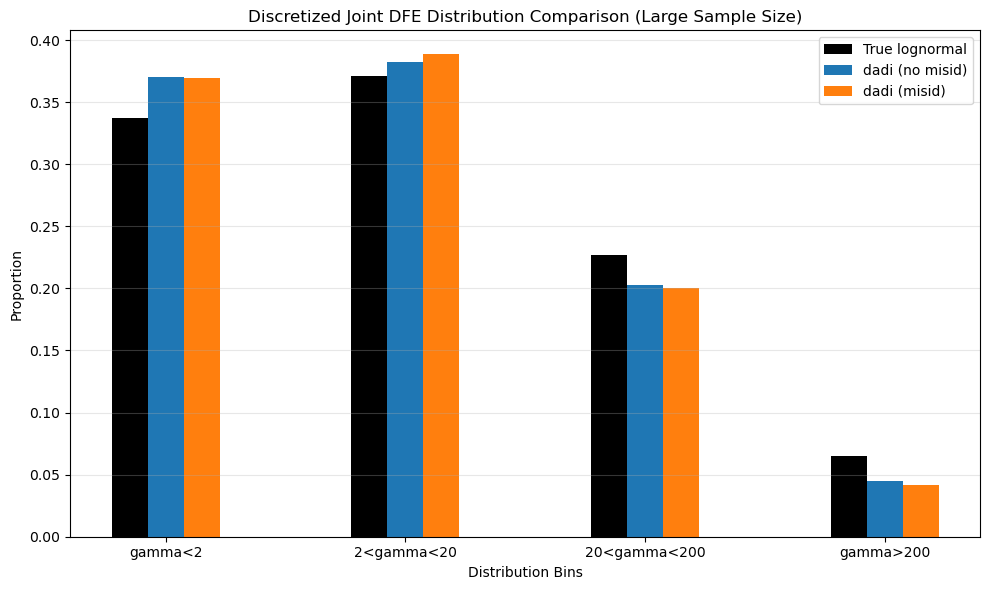

In [22]:
groups = ['true'] + dfe_methods
bin_vals = {'true': true_bins}
for method in dfe_methods:
    bin_vals[method] = average_bins(dfe_shape_scale['large'][method])

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
n_groups = len(groups)
bar_width = 0.15
bin_positions = np.arange(n_bins)

for i, group in enumerate(groups):
    offset = (i - (n_groups - 1) / 2) * bar_width
    ax.bar(bin_positions + offset, bin_vals[group], bar_width,
           label=group_labels[group], color=group_colors[group])

ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized Joint DFE Distribution Comparison (Large Sample Size)')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'dfe_discretized_large.pdf'), bbox_inches='tight')
plt.show()


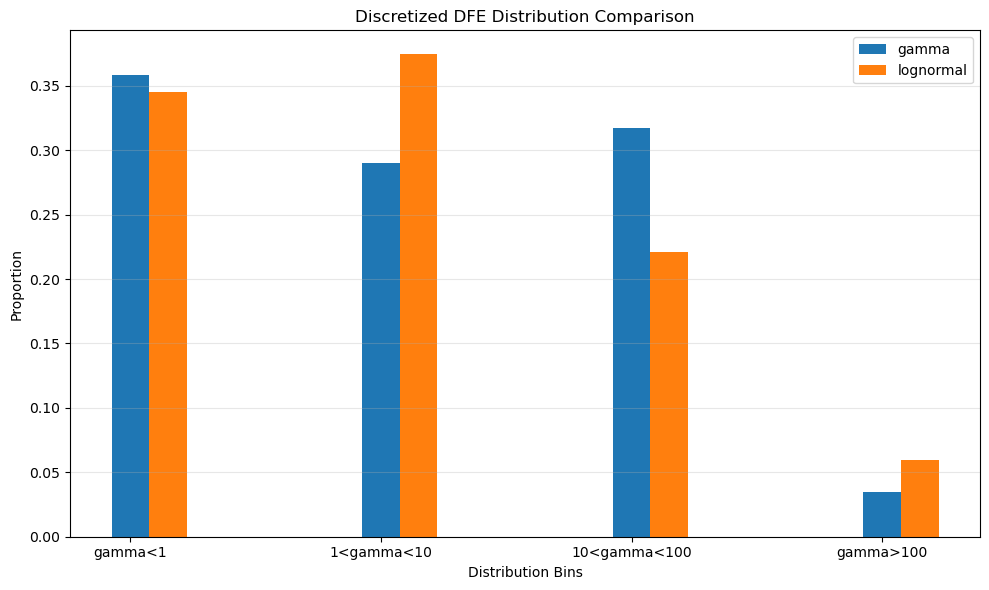

In [57]:
mu = 1.63
sigma = 2.35

adjustment = 161744*2 # 2N_e

gamma_shape = 0.27
gamma_scale = 129.4

# discretize the gamma distribution 
c1 = ssd.gamma.cdf(2, gamma_shape, scale=gamma_scale)
c10 = ssd.gamma.cdf(20, gamma_shape, scale=gamma_scale)
c100 = ssd.gamma.cdf(200, gamma_shape, scale=gamma_scale)
gamma_bins = [c1, c10 - c1, c100 - c10, 1 - c100]

# and the lognormal distribution
c1 = ssd.lognorm.cdf(2, sigma, scale=np.exp(mu))
c10 = ssd.lognorm.cdf(20, sigma, scale=np.exp(mu))
c100 = ssd.lognorm.cdf(200, sigma, scale=np.exp(mu))
lognormal_bins = [c1, c10 - c1, c100 - c10, 1 - c100]

bin_labels = ("gamma<1", "1<gamma<10", "10<gamma<100", "gamma>100", )

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
bar_width = 0.15
bin_positions = np.arange(n_bins)

ax.bar(bin_positions, gamma_bins, bar_width, label='gamma', color='C0')
ax.bar(bin_positions+.15, lognormal_bins, bar_width, label='lognormal', color='C1')
    
ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [64]:
# we want to minimize the Jensen-Shannon divergence between the discretized distributions...
import scipy.stats.distributions as ssd
from scipy.special import kl_div
from scipy.optimize import minimize

# we take the gamma bins as given
gamma_shape = 0.27
gamma_scale = 129.4

# discretize the gamma distribution 
c1 = ssd.gamma.cdf(1, gamma_shape, scale=gamma_scale)
c10 = ssd.gamma.cdf(10, gamma_shape, scale=gamma_scale)
c100 = ssd.gamma.cdf(100, gamma_shape, scale=gamma_scale)
gamma_dist = np.array([c1, c10 - c1, c100 - c10, 1 - c100])

def js_div_lognormal(x):
    """
    Jensen-Shannon divergence between a lognormal distribution and a gamma distribution.
    """
    # gamma distribution, discretized
    gamma_dist = np.array([0.29758874, 0.24853187, 0.34862282, 0.10525657])
    
    # compute the bins for the lognormal distribution
    c1 = ssd.lognorm.cdf(1, x[-1], scale=np.exp(x[0]))
    c10 = ssd.lognorm.cdf(10, x[-1], scale=np.exp(x[0]))
    c100 = ssd.lognorm.cdf(100, x[-1], scale=np.exp(x[0]))
    lognormal_dist = np.array([c1, c10 - c1, c100 - c10, 1 - c100])

    # define the mixture
    mixture = (lognormal_dist + gamma_dist)/2

    # compute the KL divergence between the mixture and each distribution
    kl_lognormal = np.sum(kl_div(lognormal_dist, mixture))
    # and for gamma
    kl_gamma = np.sum(kl_div(gamma_dist, mixture))

    return (kl_lognormal + kl_gamma)/2

x0 = [1.25, 2.5]
res = minimize(js_div_lognormal, x0, method='Nelder-Mead')
print(res.x)

[1.57415924 2.69632159]


In [ ]:
# we want to minimize the Jensen-Shannon divergence between the discretized distributions...
import scipy.stats.distributions as ssd
from scipy.special import kl_div
from scipy.optimize import minimize

# we take the gamma bins as given
gamma_shape = 0.27
gamma_scale = 129.4

# discretize the gamma distribution 
c1 = ssd.gamma.cdf(2, gamma_shape, scale=gamma_scale)
c2 = ssd.gamma.cdf(6.32455532, gamma_shape, scale=gamma_scale)
c10 = ssd.gamma.cdf(20, gamma_shape, scale=gamma_scale)
c20 = ssd.gamma.cdf(63.2455532, gamma_shape, scale=gamma_scale)
c100 = ssd.gamma.cdf(200, gamma_shape, scale=gamma_scale)
gamma_dist = np.array([c1, c2 - c1, c10 - c2, c20 - c10, c100 - c20, 1 - c100])

def js_div_lognormal(x):
    """
    Jensen-Shannon divergence between a lognormal distribution and a gamma distribution.
    """
    # gamma distribution, discretized
    gamma_dist = np.array([0.35824812, 0.12718841, 0.16276831, 0.18181731, 0.13535234, 0.03462551])
    
    # compute the bins for the lognormal distribution
    c1 = ssd.lognorm.cdf(2, x[-1], scale=np.exp(x[0]))
    c2 = ssd.lognorm.cdf(6.32455532, x[-1], scale=np.exp(x[0]))
    c10 = ssd.lognorm.cdf(20, x[-1], scale=np.exp(x[0]))
    c20 = ssd.lognorm.cdf(63.2455532, x[-1], scale=np.exp(x[0]))
    c100 = ssd.lognorm.cdf(200, x[-1], scale=np.exp(x[0]))
    lognormal_dist = np.array([c1, c2 - c1, c10 - c2, c20 - c10, c100 - c20, 1 - c100])

    # define the mixture
    mixture = (lognormal_dist + gamma_dist)/2

    # compute the KL divergence between the mixture and each distribution
    kl_lognormal = np.sum(kl_div(lognormal_dist, mixture))
    # and for gamma
    kl_gamma = np.sum(kl_div(gamma_dist, mixture))

    return (kl_lognormal + kl_gamma)/2

x0 = [1.25, 2.5]
res = minimize(js_div_lognormal, x0, method='Nelder-Mead')
print(res.x)

print(ssd.lognorm.mean(res.x[-1], scale=np.exp(res.x[0])))
print(ssd.lognorm.std(res.x[-1], scale=np.exp(res.x[0])*2))

print(1.69/np.log(2))


[1.69155136 2.37871223]
54.68721717843252
3106.410302802434
2.438154619102348


In [75]:
Q=1
m = 0.00021600000000000002*Q
alpha = 0.27
theta = m/alpha
var = alpha * theta * theta
	
	
loc = np.log(m**2 / np.sqrt(m**2 + var))
print(loc)
print(loc + np.log(2*161744/Q))
shape = np.sqrt(np.log(1 + var/m**2))
print(shape)

-9.21440726050724
3.4725100374465434
1.2443272159903367


[376193.68750372 345555.66821314 317410.63987151 291555.67886844
 267804.37688269 245985.49669361 225941.73739603 207528.60011429
 190613.34603627 175074.03925332]
[1.57670080e-05 1.95097729e-06 1.88532286e-07 1.38009385e-08
 7.39514489e-10 2.79120283e-11 7.10679278e-13 1.16281245e-14
 1.15775201e-16 6.59760867e-19]
[340221.46671407 324139.35464142 308302.89347245 292751.56485253
 277521.50159277 262645.42190582 248152.59470151 234068.83466513
 220416.52557117 207214.67004927]
[5.47763468 4.49142283 3.67663576 3.00464424 2.45138371 1.99666554
 1.62358539 1.31801616 1.06817429 0.86424981]


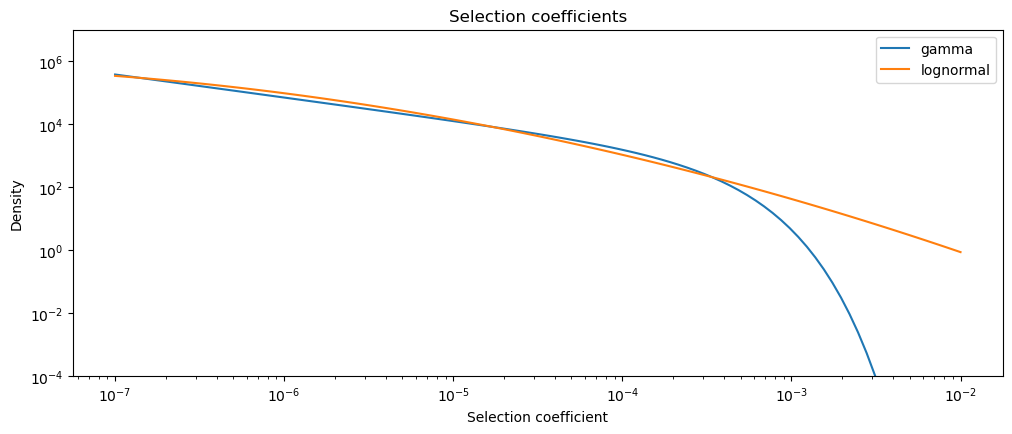

In [4]:
xx = np.logspace(-7, -2, 100)

gamma_pdf = ssd.gamma.pdf(xx, 0.27, scale=0.000216)
lognormal_pdf = ssd.lognorm.pdf(xx, 2.8478, scale=np.exp(1.36)/(2*161744))
lognormal_pdf2 = ssd.lognorm.pdf(xx, 1.24, scale=np.exp(2.77)/161744)

print(gamma_pdf[:10])
print(gamma_pdf[-10:])
print("=========")
print(lognormal_pdf[:10])
print(lognormal_pdf[-10:])

fig, ax = plt.subplots(1, 1, figsize=(12, 4.5))

ax.plot(xx, gamma_pdf, color="C0", label="gamma")
ax.plot(xx, lognormal_pdf, color="C1", label="lognormal")
#ax.plot(xx, lognormal_pdf2, color="C2", label="lognormal (old)")
ax.set_xlabel("Selection coefficient")
ax.set_ylabel("Density")
ax.set_title("Selection coefficients")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim([1e-4, 1e7])
ax.legend()

In [ ]:
import numpy as np
import scipy.stats.distributions as ssd
from scipy.integrate import quad
from scipy.optimize import minimize

gamma_shape = 0.27
gamma_scale = 129.4

def js_div_continuous(x):
    """
    Jensen-Shannon divergence between lognormal(mu=x[0], sigma=x[1]) and
    gamma(gamma_shape, gamma_scale), via numerical quadrature in log-space.
    JSD is invariant under diffeomorphisms so the result is the same.
    """
    mu, sigma = x[0], x[1]
    if sigma <= 0:
        return np.inf

    p = ssd.lognorm(sigma, scale=np.exp(mu))
    q = ssd.gamma(gamma_shape, scale=gamma_scale)

    def integrand(t):
        s = np.exp(t)
        pv = p.pdf(s) * s  # lognormal density in log-space = Gaussian(μ, σ)
        qv = q.pdf(s) * s  # gamma density in log-space
        mv = 0.5 * (pv + qv)

        result = 0.0
        if pv > 0:
            result += 0.5 * pv * np.log(pv / mv)
        if qv > 0:
            result += 0.5 * qv * np.log(qv / mv)
        return result

    val, _ = quad(integrand, -np.inf, np.inf, limit=200, epsabs=1e-10, epsrel=1e-8)
    return val

x0 = [1.25, 2.5]
res = minimize(js_div_continuous, x0, method='Nelder-Mead',
               options={'xatol': 1e-6, 'fatol': 1e-10, 'maxiter': 10000})

mu_opt, sigma_opt = res.x
print(f"Optimal parameters:  mu={mu_opt:.4f}, sigma={sigma_opt:.4f}")
print(f"Lognormal mean: {ssd.lognorm.mean(sigma_opt, scale=np.exp(mu_opt)):.4f}")
print(f"Lognormal std:  {ssd.lognorm.std(sigma_opt, scale=np.exp(mu_opt)):.4f}")
print(f"Gamma mean:     {ssd.gamma.mean(gamma_shape, scale=gamma_scale):.4f}")
print(f"Gamma std:      {ssd.gamma.std(gamma_shape, scale=gamma_scale):.4f}")
print(f"Optimal JSD:    {res.fun:.8f}")


/var/folders/47/3sc0r_t556988tw6r8vdy6d40000gp/T/ipykernel_73397/1431172470.py:27: RuntimeWarning: overflow encountered in exp
  s = np.exp(t)
/var/folders/47/3sc0r_t556988tw6r8vdy6d40000gp/T/ipykernel_73397/1431172470.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  pv = p.pdf(s) * s  # lognormal density in log-space = Gaussian(μ, σ)
/var/folders/47/3sc0r_t556988tw6r8vdy6d40000gp/T/ipykernel_73397/1431172470.py:29: RuntimeWarning: invalid value encountered in scalar multiply
  qv = q.pdf(s) * s  # gamma density in log-space


Optimal parameters:  mu=1.3606, sigma=2.8478
Lognormal mean: 224.8473
Lognormal std:  12966.4480
Gamma mean:     34.9380
Gamma std:      67.2382
Optimal JSD:    0.04504446


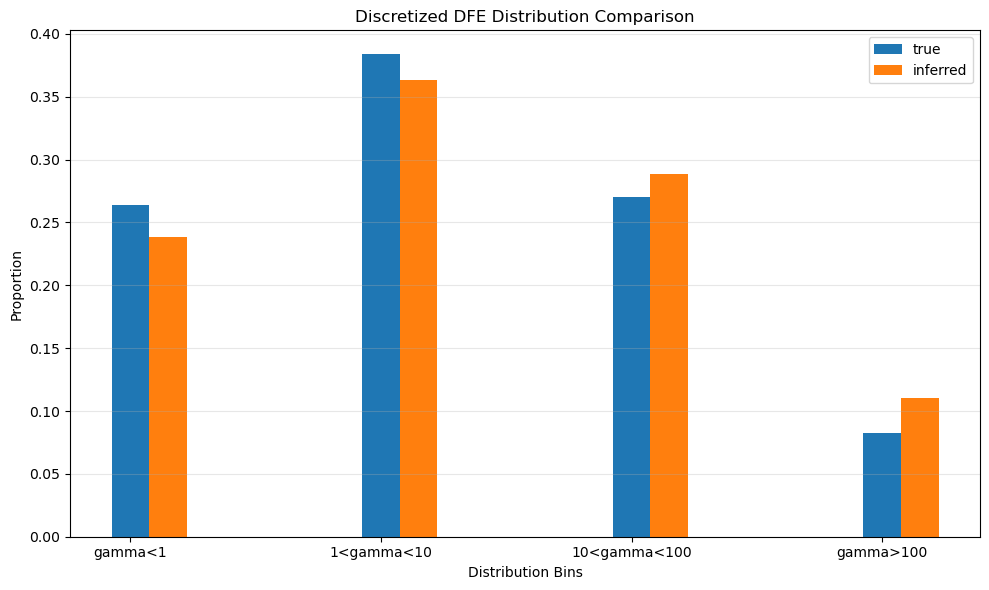

In [7]:
true_bins = discretized_bins(mu=1.438, sigma=2.28)

inferred_bins = discretized_bins(mu=1.691, sigma=2.378)

bin_labels = ("gamma<1", "1<gamma<10", "10<gamma<100", "gamma>100", )

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
bar_width = 0.15
bin_positions = np.arange(n_bins)

ax.bar(bin_positions, true_bins, bar_width, label='true', color='C0')
ax.bar(bin_positions+.15, inferred_bins, bar_width, label='inferred', color='C1')
    
ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

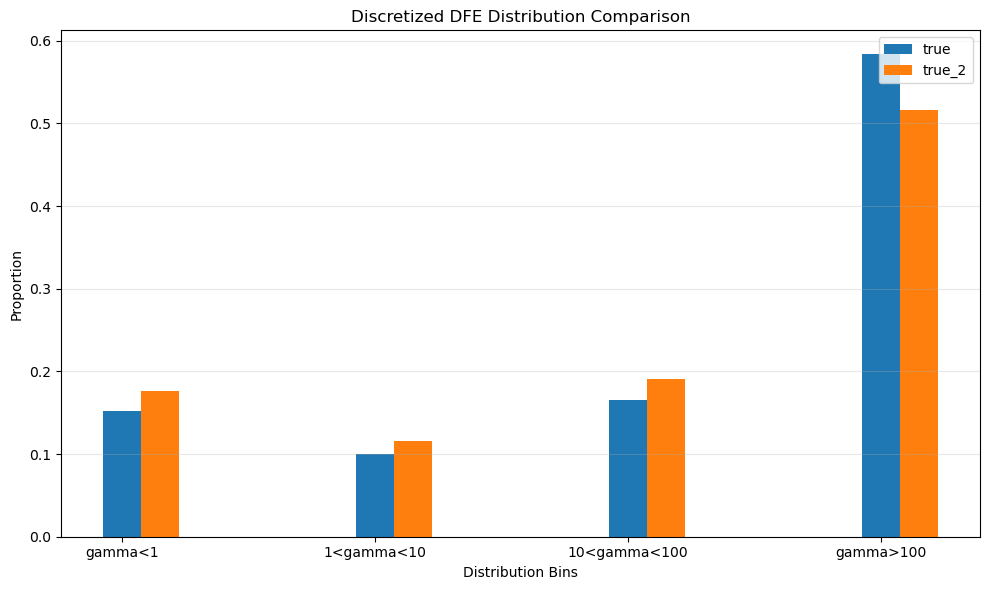

In [37]:

def discretized_bins_gamma(shape, scale):
    c1 = ssd.gamma.cdf(1, shape, scale=scale)
    c10 = ssd.gamma.cdf(10, shape, scale=scale)
    c100 = ssd.gamma.cdf(100, shape, scale=scale)
    return [c1, c10 - c1, c100 - c10, 1 - c100]

bins = discretized_bins_gamma(.22, 8000)
bins2 = discretized_bins_gamma(.22, 4000)

fig, ax = plt.subplots(figsize=(10, 6))
n_bins = len(bin_labels)
bar_width = 0.15
bin_positions = np.arange(n_bins)

ax.bar(bin_positions, bins, bar_width, label='true', color='C0')
ax.bar(bin_positions+.15, bins2, bar_width, label='true_2', color='C1')
 
ax.set_xlabel('Distribution Bins')
ax.set_ylabel('Proportion')
ax.set_title('Discretized DFE Distribution Comparison')
ax.set_xticks(bin_positions)
ax.set_xticklabels(bin_labels)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()